In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [ ]:
!apt-get install -y p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [ ]:
!7z x "/content/archive (1).zip" -o/content/cifar10


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 183819211 bytes (176 MiB)

Extracting archive: /content/archive (1).zip
  6% 4096 Open              --
Path = /content/archive (1).zip
Type = zip
Physical Size = 183819211

  0%      1% 890 - cifar10/test/airplane/9075_airplane.png                                                    2% 1769 - cifar10/test/automobile/7973_automobile.png                                                         4% 2541 - cifar10/test/bird/5859_bird.png

In [ ]:
!find "/content/cifar10" -maxdepth 3

/content/cifar10
/content/cifar10/cifar10
/content/cifar10/cifar10/labels.txt
/content/cifar10/cifar10/train
/content/cifar10/cifar10/train/cat
/content/cifar10/cifar10/train/bird
/content/cifar10/cifar10/train/airplane
/content/cifar10/cifar10/train/deer
/content/cifar10/cifar10/train/horse
/content/cifar10/cifar10/train/frog
/content/cifar10/cifar10/train/truck
/content/cifar10/cifar10/train/ship
/content/cifar10/cifar10/train/dog
/content/cifar10/cifar10/train/automobile
/content/cifar10/cifar10/test
/content/cifar10/cifar10/test/cat
/content/cifar10/cifar10/test/bird
/content/cifar10/cifar10/test/airplane
/content/cifar10/cifar10/test/deer
/content/cifar10/cifar10/test/horse
/content/cifar10/cifar10/test/frog
/content/cifar10/cifar10/test/truck
/content/cifar10/cifar10/test/ship
/content/cifar10/cifar10/test/dog
/content/cifar10/cifar10/test/automobile
/content/cifar10/readme.txt


In [ ]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/cifar10/cifar10/train",
    image_size=(32, 32),
    batch_size=64
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    "/content/cifar10/cifar10/test",
    image_size=(32, 32),
    batch_size=64,
    shuffle=False
)

Found 50000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


In [ ]:
train_dataset = train_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

test_dataset = test_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y)
)

In [ ]:
model = models.Sequential([
    layers.Conv2D(64,(3,3), activation='relu',padding='same'),

    layers.Conv2D(128,(3,3), activation='relu',padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=test_dataset
)

Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9275 - loss: 0.2068 - val_accuracy: 0.6921 - val_loss: 1.3192
Epoch 2/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9412 - loss: 0.1689 - val_accuracy: 0.6893 - val_loss: 1.3799
Epoch 3/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9477 - loss: 0.1483 - val_accuracy: 0.6849 - val_loss: 1.4366
Epoch 4/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9567 - loss: 0.1281 - val_accuracy: 0.6866 - val_loss: 1.5201
Epoch 5/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9580 - loss: 0.1237 - val_accuracy: 0.6788 - val_loss: 1.5809
Epoch 6/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9635 - loss: 0.1054 - val_accuracy: 0.6877 - val_loss: 1.6610
Epoch 7/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9653 - loss: 0.1025 - val_accuracy: 0.6867 - val_loss: 1.7394
Epoch 8/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9659 - loss: 0.0992 - 

In [ ]:
loss,acc=model.evaluate(test_dataset)

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.6862 - loss: 2.5703


In [ ]:
print(acc*100)

68.62000226974487


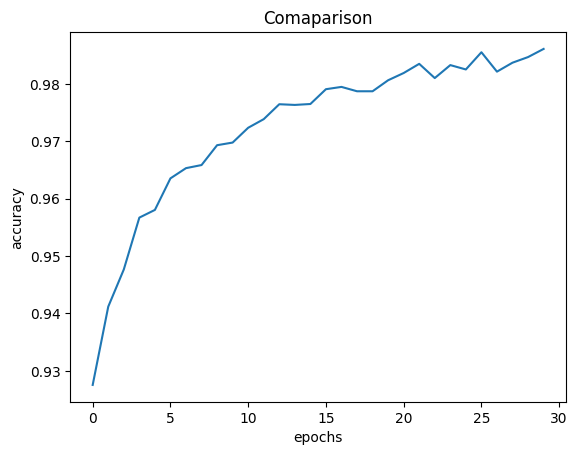

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.title('Comaparison')
plt.show()

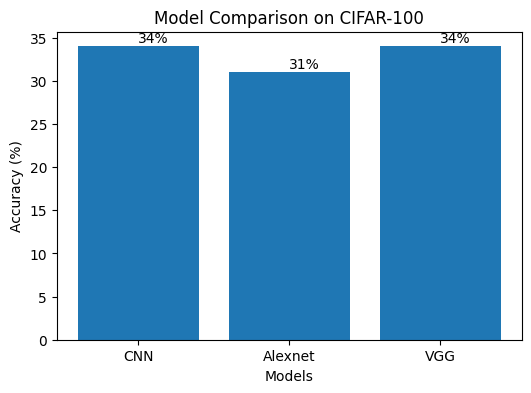

In [ ]:
import matplotlib.pyplot as plt

models=['CNN','Alexnet','VGG']
accuracy=[34,31,34]

plt.figure(figsize=(6,4))
plt.bar(models,accuracy)
plt.title('Model Comparison on CIFAR-100')
plt.xlabel('Models')
plt.ylabel('Accuracy (%)')

for i,v in enumerate(accuracy):
  plt.text(i,v+0.5,str(v)+'%')

plt.show()

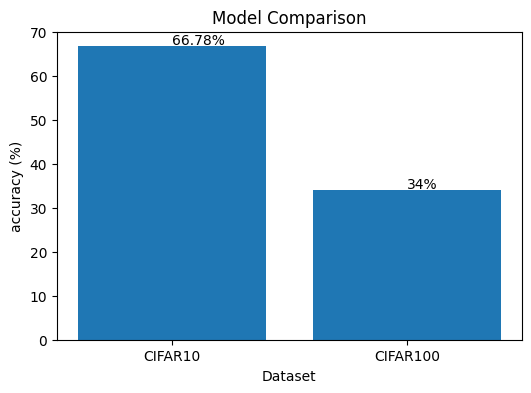

In [ ]:
import matplotlib.pyplot as plt

datasets=['CIFAR10','CIFAR100']
accuracy=[66.78,34]

plt.figure(figsize=(6,4))
plt.bar(datasets,accuracy)
plt.title('Model Comparison')
plt.xlabel('Dataset')
plt.ylabel('accuracy (%)')
for i,v in enumerate(accuracy):
  plt.text(i,v+0.5,str(v)+'%')

plt.show()